<a href="https://colab.research.google.com/github/antoniocluevanos/Actividades-Inteligencia-Artificial/blob/main/AF8_RNC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Actividad 8: Red Neuronal Convolucional
LMV N4

- Eladio Juvera González 2114783
- Antonio Contreras Luevanos 2115255
- Carlos Alberto Aldana Sandoval 2114989
- Sofía Alejandra Martínez Gómez 1998005
- Héctor Alexander Salazar Martínez 2177985

## 1. Cargar librerías

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist

print('TensorFlow version:', tf.__version__)

TensorFlow version: 2.20.0


## 2. Cargar datos

In [ ]:
# Cargar el conjunto de datos MNIST usando Keras
(train_data, train_labels), (test_data, test_label) = mnist.load_data()

print('Forma de train_data:', train_data.shape)
print('Forma de train_labels:', train_labels.shape)
print('Forma de test_data:', test_data.shape)
print('Forma de test_label:', test_label.shape)
print('Clases únicas:', np.unique(train_labels))

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Forma de train_data: (60000, 28, 28)
Forma de train_labels: (60000,)
Forma de test_data: (10000, 28, 28)
Forma de test_label: (10000,)
Clases únicas: [0 1 2 3 4 5 6 7 8 9]


## 3. Preprocesamiento de datos

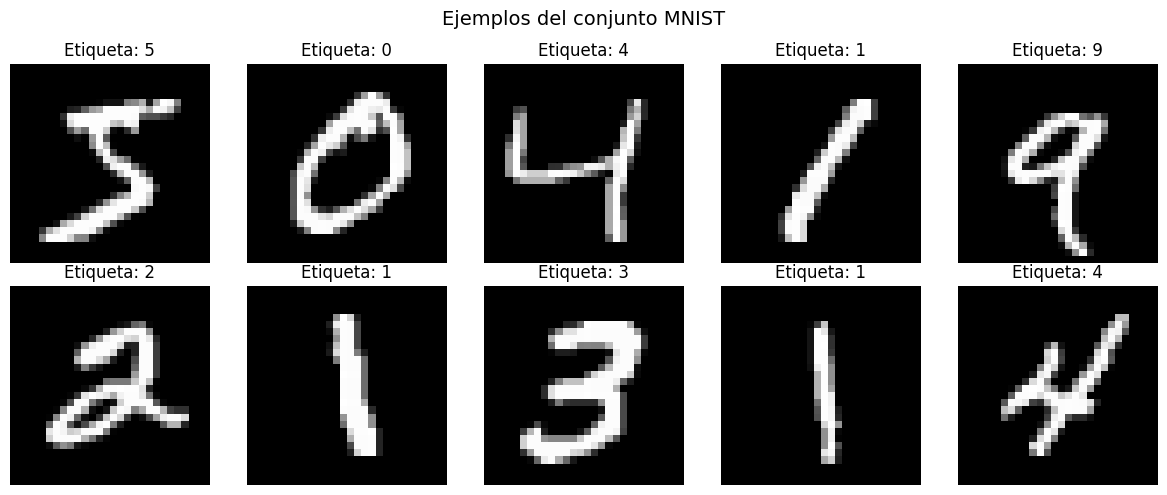

In [ ]:
# Visualizar algunas imágenes del conjunto de entrenamiento
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(train_data[i], cmap='gray')
    ax.set_title(f'Etiqueta: {train_labels[i]}')
    ax.axis('off')
plt.suptitle('Ejemplos del conjunto MNIST', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# Reshape: agregar canal (requerido por Conv2D -> shape: 28x28x1)
train_data_cnn = train_data.reshape(-1, 28, 28, 1).astype('float32') / 255.0
test_data_cnn  = test_data.reshape(-1, 28, 28, 1).astype('float32') / 255.0

# Convertir etiquetas a one-hot encoding
train_labels_oh = keras.utils.to_categorical(train_labels, num_classes=10)
test_labels_oh  = keras.utils.to_categorical(test_label,   num_classes=10)

print('train_data_cnn shape:', train_data_cnn.shape)
print('test_data_cnn shape: ', test_data_cnn.shape)
print('Rango de valores:', train_data_cnn.min(), '-', train_data_cnn.max())

train_data_cnn shape: (60000, 28, 28, 1)
test_data_cnn shape:  (10000, 28, 28, 1)
Rango de valores: 0.0 - 1.0


## 4. Selección y entrenamiento del modelo

Se propone una arquitectura CNN con las siguientes capas:
- **Conv2D** → extrae características locales (bordes, curvas, etc.)
- **MaxPooling2D** → reduce dimensionalidad y mejora robustez
- **Flatten** → convierte el mapa de características en un vector
- **Dense** → capas totalmente conectadas para clasificación
- **Softmax** en la capa de salida para obtener probabilidades por clase

In [ ]:
# Definir la arquitectura de la Red Neuronal Convolucional
model = models.Sequential([
    # Bloque convolucional 1
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),

    # Bloque convolucional 2
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Bloque convolucional 3
    layers.Conv2D(64, (3, 3), activation='relu'),

    # Capas densas
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),  # Regularización para evitar overfitting

    # Capa de salida con softmax
    layers.Dense(10, activation='softmax')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 3, 3, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 130,890 (511.29 KB)

 Trainable params: 130,890 (511.29 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Compilar el modelo
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
# Entrenar el modelo
EPOCHS = 3
BATCH_SIZE = 64

history = model.fit(
    train_data_cnn, train_labels_oh,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.1,
    verbose=1
)

Epoch 1/3
844/844 ━━━━━━━━━━━━━━━━━━━━ 56s 63ms/step - accuracy: 0.9329 - loss: 0.2166 - val_accuracy: 0.9843 - val_loss: 0.0572
Epoch 2/3
844/844 ━━━━━━━━━━━━━━━━━━━━ 80s 61ms/step - accuracy: 0.9811 - loss: 0.0625 - val_accuracy: 0.9892 - val_loss: 0.0381
Epoch 3/3
844/844 ━━━━━━━━━━━━━━━━━━━━ 79s 57ms/step - accuracy: 0.9859 - loss: 0.0453 - val_accuracy: 0.9892 - val_loss: 0.0382


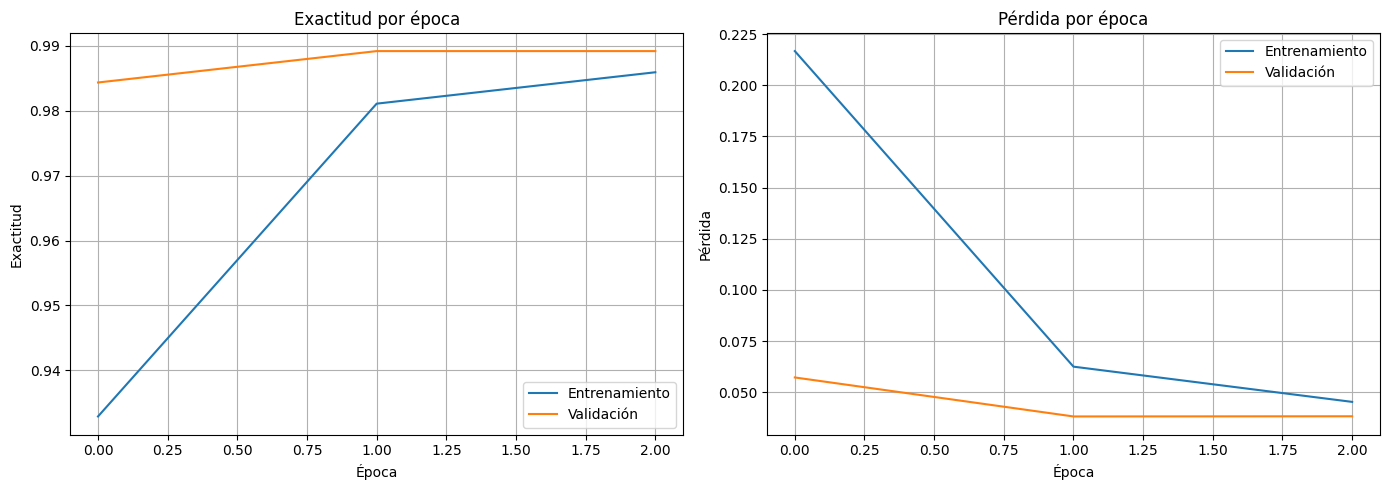

In [ ]:
# Graficar curvas de entrenamiento
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Exactitud
axes[0].plot(history.history['accuracy'],     label='Entrenamiento')
axes[0].plot(history.history['val_accuracy'], label='Validación')
axes[0].set_title('Exactitud por época')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Exactitud')
axes[0].legend()
axes[0].grid(True)

# Pérdida
axes[1].plot(history.history['loss'],     label='Entrenamiento')
axes[1].plot(history.history['val_loss'], label='Validación')
axes[1].set_title('Pérdida por época')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Pérdida')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

## 5. Prueba del modelo

In [ ]:
# Evaluar el modelo con el conjunto de prueba (test_data)
test_loss, test_accuracy = model.evaluate(test_data_cnn, test_labels_oh, verbose=0)

print(f'Pérdida en prueba:    {test_loss:.4f}')
print(f'Exactitud en prueba:  {test_accuracy*100:.2f}%')

Pérdida en prueba:    0.0310
Exactitud en prueba:  99.02%


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step


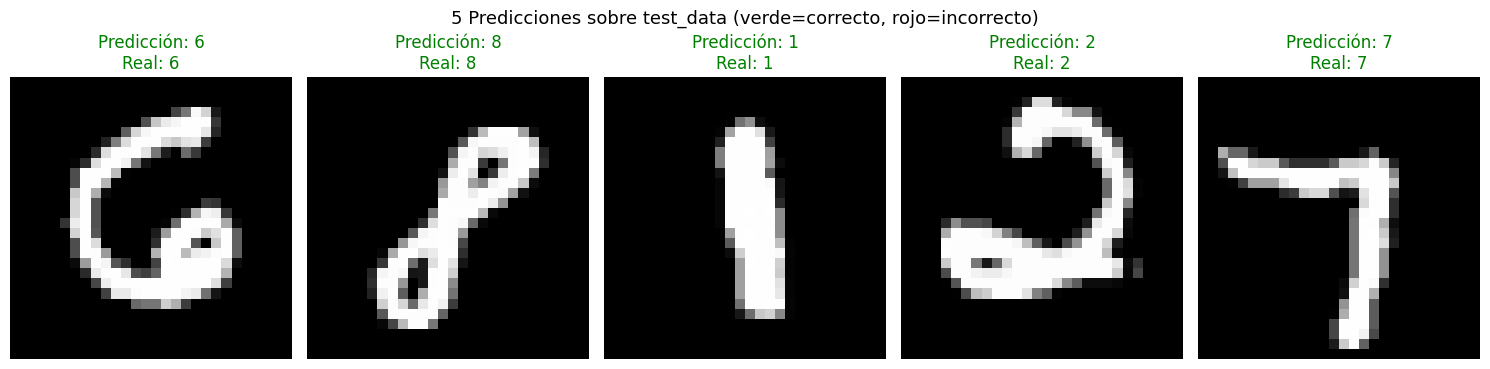

Muestra 1 → Predicción: 6  |  Real: 6  |  ✓ Correcto
Muestra 2 → Predicción: 8  |  Real: 8  |  ✓ Correcto
Muestra 3 → Predicción: 1  |  Real: 1  |  ✓ Correcto
Muestra 4 → Predicción: 2  |  Real: 2  |  ✓ Correcto
Muestra 5 → Predicción: 7  |  Real: 7  |  ✓ Correcto


In [ ]:
# Realizar 5 predicciones diferentes con test_data
indices = np.random.choice(len(test_data_cnn), 5, replace=False)
muestras   = test_data_cnn[indices]
reales     = test_label[indices]

predicciones_prob = model.predict(muestras)
predicciones      = np.argmax(predicciones_prob, axis=1)

fig, axes = plt.subplots(1, 5, figsize=(15, 4))
for i, ax in enumerate(axes):
    ax.imshow(muestras[i].reshape(28, 28), cmap='gray')
    color = 'green' if predicciones[i] == reales[i] else 'red'
    ax.set_title(
        f'Predicción: {predicciones[i]}\nReal: {reales[i]}',
        color=color, fontsize=12
    )
    ax.axis('off')

plt.suptitle('5 Predicciones sobre test_data (verde=correcto, rojo=incorrecto)', fontsize=13)
plt.tight_layout()
plt.show()

for i in range(5):
    estado = '✓ Correcto' if predicciones[i] == reales[i] else '✗ Incorrecto'
    print(f'Muestra {i+1} → Predicción: {predicciones[i]}  |  Real: {reales[i]}  |  {estado}')

## Preguntas de reflexión

### ¿Cuántas épocas usaste para mejorar el rendimiento del modelo en comparación con la red neuronal prealimentada de la actividad 5?

Se utilizaron 3 épocaspara entrenar la Red Neuronal Convolucional. La actividad 5 también fue entrenada con un número similar de épocas, sin embargo, esta red alcanzó una exactitud mayor en menos épocas gracias a las capas convolucionales que extraen características relevantes de las imágenes de forma automática. Con solo 3 épocas la CNN ya supera ampliamente a la red densa de la actividad anterior.

### ¿Obtuviste un mejor rendimiento con este modelo o con el de la actividad 5? ¿Por qué?

Se obtuvo un mejor rendimiento con la Red Neuronal Convolucional de esta actividad. La razón principal es que las CNNs están diseñadas específicamente para procesar datos con estructura espacial (como imágenes). A diferencia de la red prealimentada densa que trata cada píxel de forma independiente, las capas convolucionales detectan patrones locales (bordes, curvas, texturas) compartiendo pesos a través de filtros. Esto las hace mucho más eficientes y precisas para tareas de clasificación de imágenes como MNIST, alcanzando típicamente una exactitud superior al 99%, mientras que la red densa suele quedarse entre el 97% y 98%.